In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import os

processed_path = r"C:\Users\egkbo\dallas_heat_island\data\processed"

# load master dataframe
master = gpd.read_file(os.path.join(processed_path, "master.gpkg"))

print("Master shape:", master.shape)
print("\nColumns:", master.columns.tolist())
print("\nMissing values:")
print(master.isna().sum())

Master shape: (645, 13)

Columns: ['geoid', 'aland', 'awater', 'intptlat', 'intptlon', 'area_sqkm', 'median_income', 'total_population', 'total_units', 'pct_old_housing', 'lst_celsius', 'ndvi_mean', 'geometry']

Missing values:
geoid                0
aland                0
awater               0
intptlat             0
intptlon             0
area_sqkm            0
median_income       15
total_population     0
total_units          0
pct_old_housing      3
lst_celsius          0
ndvi_mean            0
geometry             0
dtype: int64


Prepare Data

In [2]:
# define features and target
features = ["ndvi_mean", "median_income", "total_population", 
            "pct_old_housing", "area_sqkm", "intptlat", "intptlon"]
target = "lst_celsius"

# drop rows with missing values
model_df = master[features + [target]].dropna()

print("Rows after dropping missing values:", len(model_df))
print("Rows dropped:", len(master) - len(model_df))

# define X and y
X = model_df[features]
y = model_df[target]

print("\nFeature shapes:", X.shape)
print("Target shape:", y.shape)

Rows after dropping missing values: 630
Rows dropped: 15

Feature shapes: (630, 7)
Target shape: (630,)


In [3]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 504
Testing rows: 126


In [4]:
# model 1 - random forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

# model 2 - xgboost
xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

# evaluate both
print("=== RANDOM FOREST ===")
print(f"R²:   {r2_score(y_test, rf_preds):.4f}")
print(f"RMSE: {mean_squared_error(y_test, rf_preds)**0.5:.4f}")
print(f"MAE:  {mean_absolute_error(y_test, rf_preds):.4f}")

print("\n=== XGBOOST ===")
print(f"R²:   {r2_score(y_test, xgb_preds):.4f}")
print(f"RMSE: {mean_squared_error(y_test, xgb_preds)**0.5:.4f}")
print(f"MAE:  {mean_absolute_error(y_test, xgb_preds):.4f}")

=== RANDOM FOREST ===
R²:   0.8877
RMSE: 2.7814
MAE:  1.9200

=== XGBOOST ===
R²:   0.9083
RMSE: 2.5123
MAE:  1.9274


Explaining prediction for hottest tract in test set
Actual LST: 49.92°C
Predicted LST: 49.91°C


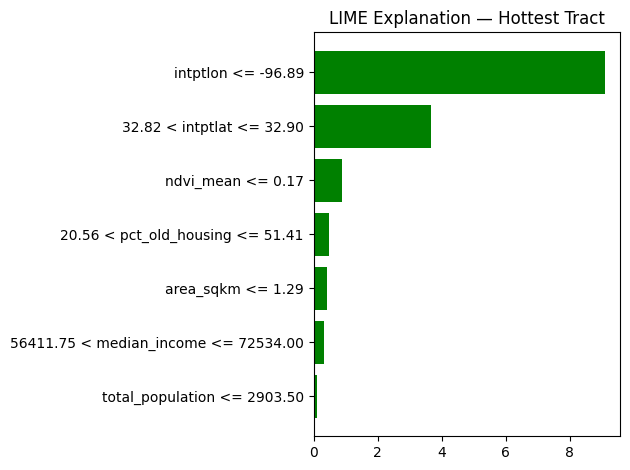

In [6]:
import lime
import lime.lime_tabular

# create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=features,
    mode="regression"
)

# explain the hottest tract in our test set
hottest_idx = y_test.values.argmax()
hottest_tract = X_test.values[hottest_idx]

print(f"Explaining prediction for hottest tract in test set")
print(f"Actual LST: {y_test.values[hottest_idx]:.2f}°C")
print(f"Predicted LST: {xgb_model.predict([hottest_tract])[0]:.2f}°C")

# generate explanation
exp = explainer.explain_instance(
    hottest_tract,
    xgb_model.predict,
    num_features=7
)

# plot explanation
fig = exp.as_pyplot_figure()
plt.title("LIME Explanation — Hottest Tract")
plt.tight_layout()
plt.show()

Location (intptlon) has the biggest impact. The tract is in the western part of Dallas, which is the hottest zone. The location (intptlat) also contributes, as the tract is in a high heat zone. The low NDVI means this area has very little vegetation, which contributes to the heat. Finally, this is in a lower middle class area with a smaller population.

Actual LST: 6.57°C
Predicted LST: 12.32°C


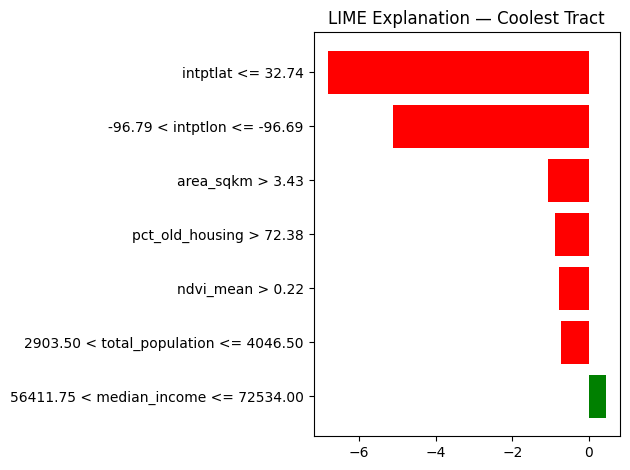

In [7]:
# explain the coolest tract in test set
coolest_idx = y_test.values.argmin()
coolest_tract = X_test.values[coolest_idx]

print(f"Actual LST: {y_test.values[coolest_idx]:.2f}°C")
print(f"Predicted LST: {xgb_model.predict([coolest_tract])[0]:.2f}°C")

exp_cool = explainer.explain_instance(
    coolest_tract,
    xgb_model.predict,
    num_features=7
)

fig = exp_cool.as_pyplot_figure()
plt.title("LIME Explanation — Coolest Tract")
plt.tight_layout()
plt.show()

The location (intptlat) is in southern Dallas, which is a cooler area near White Rock Lake. This is a larger tract, which means it likely has more vegetation (seen by the higher NDVI mean) and water. The tract has a moderate population and lower middle class income.

In [ ]:
# add predicted LST and risk tiers to master
model_df_full = master[features].dropna()
master_valid = master.dropna(subset=features)
master_valid = master_valid.copy()
master_valid["lst_predicted"] = xgb_model.predict(model_df_full[features])

# create risk tiers based on actual LST
# middle numbers in the bins are used for intervals, etc.
master_valid["heat_risk"] = pd.cut(master_valid["lst_celsius"],
    bins=[0, 30, 38, 44, 100],
    labels=["Low", "Moderate", "High", "Extreme"])

print("Heat risk distribution:")
print(master_valid["heat_risk"].value_counts())

# save final master
master_valid.to_file(os.path.join(processed_path, "master_final.gpkg"), driver="GPKG")
print("\nFinal master saved!")

Heat risk distribution:
heat_risk
Extreme     228
High        154
Moderate    144
Low         104
Name: count, dtype: int64

Final master saved!


Extreme: > 44 degrees celsius, 36%
High: 38-44 degrees celsius, 24%
Moderate: 30-38 degrees celsius, 23%
Low: < 30 degrees celsius, 17%